In [2]:
import os
import openai
import random
from dotenv import load_dotenv, find_dotenv
_ = load_dotenv(find_dotenv())
openai.api_key = os.getenv("OPENAI_API_KEY")


In [3]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated
from langchain_openai import ChatOpenAI
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, ToolMessage, AIMessage
from langchain_openai import ChatOpenAI
from langchain.schema.output_parser import StrOutputParser
from IPython.display import Image, display
from langchain_community.document_loaders import WebBaseLoader
from langchain_core.tools import tool
from tempfile import TemporaryDirectory
from typing import Dict, Optional
from typing_extensions import TypedDict, List, Any
from typing import List, Optional, Literal
from pydantic import BaseModel, ValidationError, Field, field_validator
from langgraph.types import interrupt
from langgraph.checkpoint.memory import MemorySaver
import uuid

import json

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [4]:
#------------------------------------------------------- TYPED DICT -------------------------------------------------------#

class AgentState(TypedDict):
    input: Any
    messages: List[Any]
    corrigido: str
    decision: str 

In [5]:
#------------------------------------------------------- BASE MODEL -------------------------------------------------------#

class CorretorReuslt(BaseModel):
    file_name: str = Field(description="Nome do arquivo que foi modificado")
    correct_content: str = Field(description="Conteúdo corrigido do arquivo")

class WriteResult(BaseModel):
    file_name: str = Field(description="Nome do arquivo criado")
    content: str = Field(description="Conteúdo criado")

class SupervisorDecision(BaseModel):
    action: Literal["Corretor", "Write"] = Field(description="Ação a ser executada")

class FinalAnswer(AgentState):
    resumo : str = Field(description="Um resumo curto e simples do que foi feito")
    arquivos_modificados : str = Field(description="arquivos que foram modificados")
    




In [6]:
#------------------------------------------------------- LLM and TOOLS -------------------------------------------------------#
model = ChatOpenAI(model="gpt-4.1-mini", temperature=0)



@tool
def read_file(arquivoteste: str) -> str:
    """Lê o conteúdo de um arquivo com base no nome do arquivo fornecido."""
    try:
        with open(arquivoteste, 'r') as file:
            return file.read()
    except FileNotFoundError:
        return "Arquivo não encontrado."
    
@tool
def write_file(arquivoteste: str, content: str) -> str:
    """"Escreve o conteúdo em um arquivo com base no nome do arquivo fornecido."""
    with open(arquivoteste, 'w') as file:
        file.write(content)
    return f"Conteúdo atualizado em {arquivoteste} com sucesso."


tools = [read_file, write_file]
llm_with_tools = model.bind_tools(tools)


In [ ]:
class Agent:
     #------------------------------------------------------- GRAPHS and EDGES -------------------------------------------------------#
     def __init__(self, model, checkpointer):
     
          self.model=model
          graph = StateGraph(AgentState)
          self.structured_llm = self.model.with_structured_output(FinalAnswer)
          
          # Nós do grafo
          graph.add_node("Supervisor", self.supervisor)
          graph.add_node("Human ITL", self.human_itl)
          graph.add_node("Interrupt", self.interrupt)
          graph.add_node("Corretor", self.corretor)
          graph.add_node("Write", self.update_file)
          

          graph.set_entry_point("Supervisor")
          graph.add_conditional_edges("Supervisor", self.supervisor_router, {
               "Human ITL": "Human ITL",
               "Corretor": "Corretor",      
               "Write": "Write",  
            } )
          graph.add_edge("Human ITL", "Interrupt") #human leva ao interrupt.
          graph.add_edge("Interrupt", "Supervisor") #interrupt leva ao supervisor.
          graph.add_edge("Corretor", END)
          graph.add_edge("Write", END)

          self.graph = graph.compile(checkpointer=checkpointer, interrupt_before=["Interrupt"])
          
          png = self.graph.get_graph().draw_mermaid_png()
          display(Image(png))
          
     #------------------------------------------------------- STATES -------------------------------------------------------#  
     
     def human_itl(self, state: AgentState):
          input_usuario = state['input']
          pergunta_agente = self.model.invoke(f"""Você é um assistente que solicita informações necessárias para que o fluxo possa continuar. O usuário solicitou a seguinte ação: {input_usuario.content}.
          Solicite as informações necessárias para que os outros responsáveis possam realizar o trabalho (editar; corrgir; ajustar; criar ou alterar um arquivo).""")
          
          state['messages'] = state.get('messages', []) + [AIMessage(content=pergunta_agente.content)]
          return state
     
     def interrupt(self, state: AgentState):
      
          return state
          
          

     def supervisor(self, state: AgentState):
          input_usuario = state['input']
          decision = self.model.invoke(f"""Você é um supervisor que delega tarefas com base em informações fornecidas. O usuário solicitou a seguinte ação: '{input_usuario.content}'.

        Analise a solicitação e responda com UMA das seguintes opções:
        - "Corretor": Se a ação envolver corrigir, revisar, ajustar ou alterar um arquivo existente e as informações forem claras (ex: nome do arquivo está presente).
        - "Write": Se a ação envolver escrever um conteúdo em um arquivo novo e as informações forem claras.
        - "Human ITL": Se a solicitação for ambígua, vaga ou faltarem informações essenciais para realizar a tarefa (ex: "corrija o arquivo" sem dizer qual).
          Caso a solicitação contenha as informações necessárias para prosseguir, NÃO escolha "Human ITL".
        Responda apenas com uma das três opções.""")
          state ['decision'] = decision.content.strip()
          return state
     
     def supervisor_router(self, state: AgentState):
          return state['decision']


     def corretor(self, state: AgentState):
          input_usuario = state['input']
          tools = [read_file, write_file]
          llm_with_tools = self.model.bind_tools(tools)
          corretor_llm = self.model.with_structured_output(CorretorReuslt)

          
          results = []
          resposta = llm_with_tools.invoke([HumanMessage(content=f"O usuário solicitou: '{input_usuario.content}'. "
                  "Primeiro, identifique o nome do arquivo e use a ferramenta 'read_file' para ler seu conteúdo. "
                  "Depois, com base no pedido do usuário, gere o novo conteúdo completo para o arquivo. "
                  "Finalmente, use a ferramenta 'write_file' para salvar o novo conteúdo no arquivo original.")])
          
          if resposta.tool_calls:

               call = resposta.tool_calls[0]
               
               if call["name"] == "read_file":
                    conteudo = read_file.invoke(call["args"])

                    if "Erro:" in conteudo:
                              resultado = corretor_llm.invoke(f"A operação falhou com a mensagem: '{conteudo}'.")
                    else:
                         corrigido = self.model.invoke(f"O usuário quer fazer a seguinte alteração no conteúdo de um arquivo: '{input_usuario.content}' Aqui está o conteúdo atual do arquivo: '''{conteudo}'''. Por favor, faça as alterações necessárias conforme solicitado pelo usuário. Forneça apenas o conteúdo corrigido, sem explicações adicionais.")
                         state['corrigido'] = corrigido.content
                         nome_arquivo = call["args"]["arquivoteste"]
                         write_file.invoke({
                    "arquivoteste": nome_arquivo, 
                    "content": corrigido.content})
                         
                    resultado_pydantic = CorretorReuslt(
                    file_name=nome_arquivo,
                    correct_content=corrigido.content
                          )

                          
                    results.append(AIMessage(content=json.dumps(resultado_pydantic.model_dump(), ensure_ascii=False)))
               else:
                    resultado = corretor_llm.invoke("Erro de lógica - arquivo não foi lido primeiro. Gere resposta JSON estruturada indicando falha.")
                    results.append(AIMessage(content=json.dumps(resultado.model_dump(), ensure_ascii=False)))
          else:
               resultado = corretor_llm.invoke("O agente não conseguiu determinar uma ação. Gere resposta JSON estruturada indicando falha.")
               results.append(AIMessage(content=json.dumps(resultado.model_dump(), ensure_ascii=False)))

     
          state['messages'] = state.get('messages', []) + results
          return state
     
          
          
          
     def update_file(self, state: AgentState):
          input_usuario = state['input']
          tools = [read_file, write_file]
          llm_with_tools = self.model.bind_tools(tools)
          write_llm = self.model.with_structured_output(WriteResult)
          
          resposta = llm_with_tools.invoke([HumanMessage(content=f""" O usuário solicitou: {input_usuario} você tem a sua disposição as tools {tools} para te auxiliar""")])
          results = []
          if resposta.tool_calls:
               call = resposta.tool_calls[0]
        
               if call["name"] == "write_file":
                    write_file.invoke(call["args"])
          
                    resultado_pydantic = WriteResult(
                    file_name=call["args"]["arquivoteste"],
                    content=call["args"]["content"]
               )
                    results.append(AIMessage(content=json.dumps(resultado_pydantic.model_dump(), ensure_ascii=False)))
               else:
            
                    resultado = write_llm.invoke("Erro de lógica - a ferramenta 'write_file' não foi chamada como esperado. Gere resposta JSON estruturada indicando falha.")
                    results.append(AIMessage(content=json.dumps(resultado.model_dump(), ensure_ascii=False)))
          else:
        
           resultado = write_llm.invoke("O agente não conseguiu determinar uma ação de escrita baseada no pedido. Gere resposta JSON estruturada indicando falha.")
           results.append(AIMessage(content=json.dumps(resultado.model_dump(), ensure_ascii=False)))

    
          state['messages'] = state.get('messages', []) + results
          return state
     
         


         

In [8]:


model = ChatOpenAI(model="gpt-4.1-mini", temperature=0)




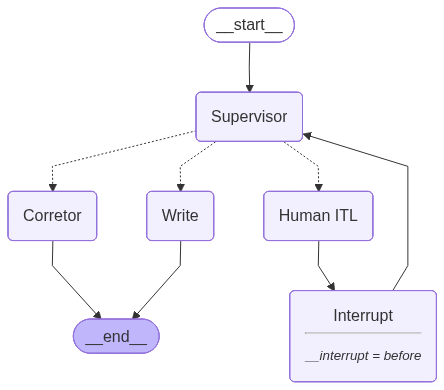

In [12]:
#------------------------------------------------------- EXECUTE -------------------------------------------------------#

if __name__ == "__main__":
    memory = MemorySaver()

    agent = Agent(model, memory)

    thread_id = str(uuid.uuid4())
    config = {"configurable": {"thread_id": thread_id}}

# INPUT INICIAL (Humano)
    initial_input = HumanMessage(content="Corrija o arquivo: ")

    events = agent.graph.stream({"input": initial_input}, config=config)
    for event in events:
        pass 
    snapshot = agent.graph.get_state(config)
    if "Interrupt" in snapshot.next: 

# HTL Solicitando mais informações ao usuário
        print(f"\n--- As informações enviadas não foram suficientes. Solicitando mais informações ao usuário. Iniciando fluxo HTL. ---")
    
    
        pergunta_agente = snapshot.values['messages'][-1].content
    
        print(f"{pergunta_agente}")
        resposta_user = input("Resposta: ")

# Corrigido para o supervisor
        novo_input_completo = (
            f"O pedido original era '{snapshot.values['input'].content}'. "
            f"O usuário respondeu à pergunta do agente '{pergunta_agente}' com: '{resposta_user}'."
        )
        
    # Fim do Interrupt
        print("\n Retomando o fluxo com a informação completa")
        
        events = agent.graph.stream(
        {"input": HumanMessage(content=novo_input_completo)},
        config=config
         )

        for event in events:
            pass

        print("\n\n Finalizando")
        final_state = agent.graph.get_state(config)
        print("Resposta final:", final_state.values['messages'][-1].content)
